In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import muon as mu
import builtins #this is because np is shadowing built in sum but can be overwritten using builtins
import scipy.stats as st
from scipy.stats import entropy

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#1. Colours, variable, settings, data

In [3]:
#Plot settings
bar_width = 0.75

In [5]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

In [6]:
patients = ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08']
patients2 = ['P01', 'P03', 'P11', 'P12', 'P09', 'P17', 'P18',  'P02', 'P08', 'C1', 'C2', 'C3', 'C4', 'C5']
controls = ['C1', 'C2', 'C3', 'C4', 'C5']
ppats = ['P17', 'P18', 'P02', 'P08'] #populate a list of patients who progress

#Manually key in responses 
responses = [['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'], ['Baseline_Dx', 'Responder', 'Responder'],
            ['Baseline_Dx', 'Non-responder', 'Responder'],
             ['Baseline_Dx', 'Responder', 'Non-responder'], ['Baseline_Dx', 'Responder', 'Non-responder'],            
            ['Baseline_Dx', 'Non-responder', 'Non-responder'],['Baseline_Dx', 'Non-responder', 'Non-responder']]

pt_res = dict(zip(patients, responses))

lclusters = ['2','6','17','21','5','16','12', '1','11','24','4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9'] #ordered cluster list
lclusters_int = [int(i) for i in lclusters]

ordered_categories_h_leiden_str = ['Atyp','2','6','17','21','5','16','12', '1','11','24']
ordered_categories_h_leiden = ['Atyp',2,6,17,21,5,16,12,1,11,24]

ordered_categories_a_leiden_str = ['4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9','HSPC-L']
ordered_categories_a_leiden = [4, 0, 19, 3, 10, 7, 15, 23, 18, 14, 8, 20, 22, 13, 9,'HSPC-L']

h_leiden = [2,6,17,21,5,16,12,1,11,24]
h_leiden_str = [str(i) for i in h_leiden]

a_leiden = [4, 0, 19, 3, 10, 7, 15, 23, 18, 14, 8, 20, 22, 13, 9]
a_leiden_str = [str(i) for i in a_leiden]

In [12]:
#Read in data from master h5mu file
adata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'rna')
print(adata.shape)

(38231, 28762)


In [13]:
#Put celltype proprotions into a df
#Put patient proportions into a dataframe

#First add in harmonised timepoints

df_props = None

time_dict = dict(zip(['C1D1', 'C1D8', 'C6D8', 'C7D1', 'C7D22', 'Progression', 'Healthy', 'C12D29'], ['C1', 'C1', 'C7', 'C7', 'C7', 'End', 'Healthy', 'End'])) #manualcreation of time harmonisation

adata0 = adata.obs.copy()
# adata0['time'] = adata0['timepoint'].replace(time_dict) #Time now integrated
adata0 = adata0.loc[~adata0['time'].isin(['Healthy'])]

for i, p in enumerate(patients):
    for t in ['C1', 'C7', 'End']: 

        adata1 = adata0.loc[(adata0['time'] == t) & (adata0['patient_alias']==p)]

        # Calculate proportions of each cell type
        df = pd.DataFrame(adata1['leiden'].value_counts(normalize=True) * 100).reset_index()
        df.columns = ['leiden', 'proportion']

        #Get the total proportion of atypical cells and add in to dataframe
        atyp = df.loc[df['leiden'].isin(a_leiden_str)]['proportion'].sum()
        heal = df.loc[df['leiden'].isin(h_leiden_str)]['proportion'].sum()

        df.loc[len(df)] = ['Atyp', atyp] 
        df.loc[len(df)] = ['HSPC-L', heal] 

        #Add extra annotation columns
        df['patient_alias'] = p
        df['timepoint'] = t       

        if df_props is None:
            df_props = df.copy()
        else:
            df_props = pd.concat([df_props, df],ignore_index = True)

#df_props

In [16]:
#2. Healthy clusters

In [18]:
#Readin the count data (from the Oral AZA supp tables)
cdata = pd.read_excel('../Data/Clinical_counts.xlsx')

In [20]:
#Cutoffs for "healthy" range gray boxes
Hb = 100
Plt = 100
Neut = 1
blast = 35

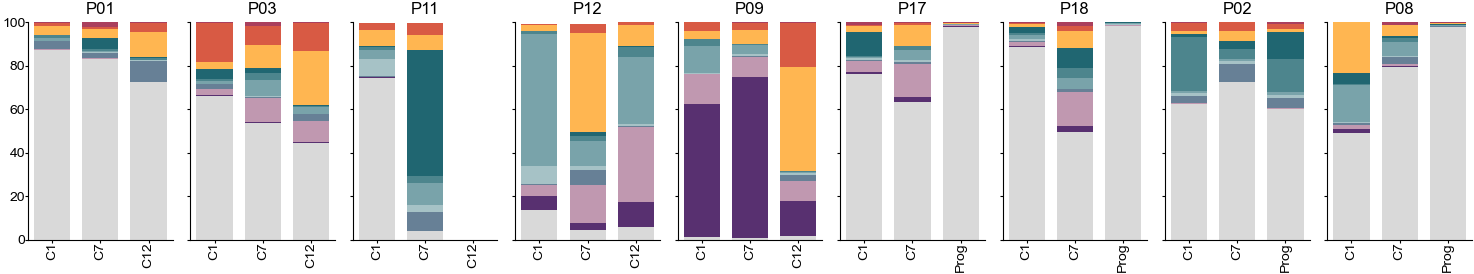

In [22]:
#Plots emphasising HSPCs vs atypical

fig, ax = plt.subplots(1,9, figsize = (15, 3))

for i, p in enumerate(patients):
    for k, t in enumerate(['C1', 'C7', 'End']):
        df = df_props.loc[(df_props['patient_alias']==p) & (df_props['timepoint']==t)]
        if ((p == 'P11') & (t == 'End')):
            ax[i].bar(k,
             100,
             bar_width,
             bottom = bottom,
             color = '#ffffff') #dummy bar plotted where data is missing
        elif df.empty:
            continue
        else:
            # Sum of all proportions = total bar height
            total_height = df['proportion'].sum()
            
            #Turn df into a dictionary
            proportion_dict = dict(zip(df.leiden, df.proportion))
            
            #plot the bar graphs
            bottom = 0
            for category in ordered_categories_h_leiden_str:
                height = proportion_dict.get(category, 0)
                if category == 'Atyp':
                    color = colors_dict[category]
                else:
                    color = colors_dict[int(category)]
                ax[i].bar(k,
                         height,
                         bar_width,
                         bottom = bottom,
                         color = color)
                
                bottom += height #update bottom value for next plot
        
    ax[i].set_ylim(0,100)
    ax[i].set_title(f'{p}',  y = 1.0)
    ax[i].set_xticks([0,1,2])
    if p in ppats:
        ax[i].set_xticklabels(['C1', 'C7', 'Prog'], rotation=90)
    else:
        ax[i].set_xticklabels(['C1', 'C7', 'C12'], rotation=90)
    ax[i].tick_params(length=2, pad=0)
    ax[i].spines['top'].set_visible(False) 
    ax[i].spines['right'].set_visible(False) 
    ax[i].set_xlim(-0.5, 2.5)


# #Proxy artist for legend
# leg_pal = {}
# for m in ordered_categories_h_leiden:

#     if m == 'Atyp':
#         leg_pal[m] = colors_dict[m]
#     else:
#         leg_pal[int(m)] = colors_dict[m] 
    
# handles = []
# f, a = plt.subplots()

# for lab in ordered_categories_h_leiden:
#     print(lab)
#     line = a.scatter([0], [0], label=lab, color=colors_dict[lab], marker = 's', s = 80, linewidth = 1)
#     handles.append(line)    
# plt.close(f)

# labs = [cluster_name[i] for i in leg_pal.keys()]

# ax[4].legend(handles = handles, labels = labs, loc = 'upper center',bbox_to_anchor = [0.5,-0.2], ncol = 11, columnspacing = 0.1, handletextpad=0.1, markerscale = 1)

for g in range(8):
    ax[g+1].set_yticklabels('')

fig.tight_layout()

#fig.savefig('../Figures/2_HSPC_proportions_leiden_v1_GEO.pdf',bbox_inches='tight', format='pdf', dpi = 600)   

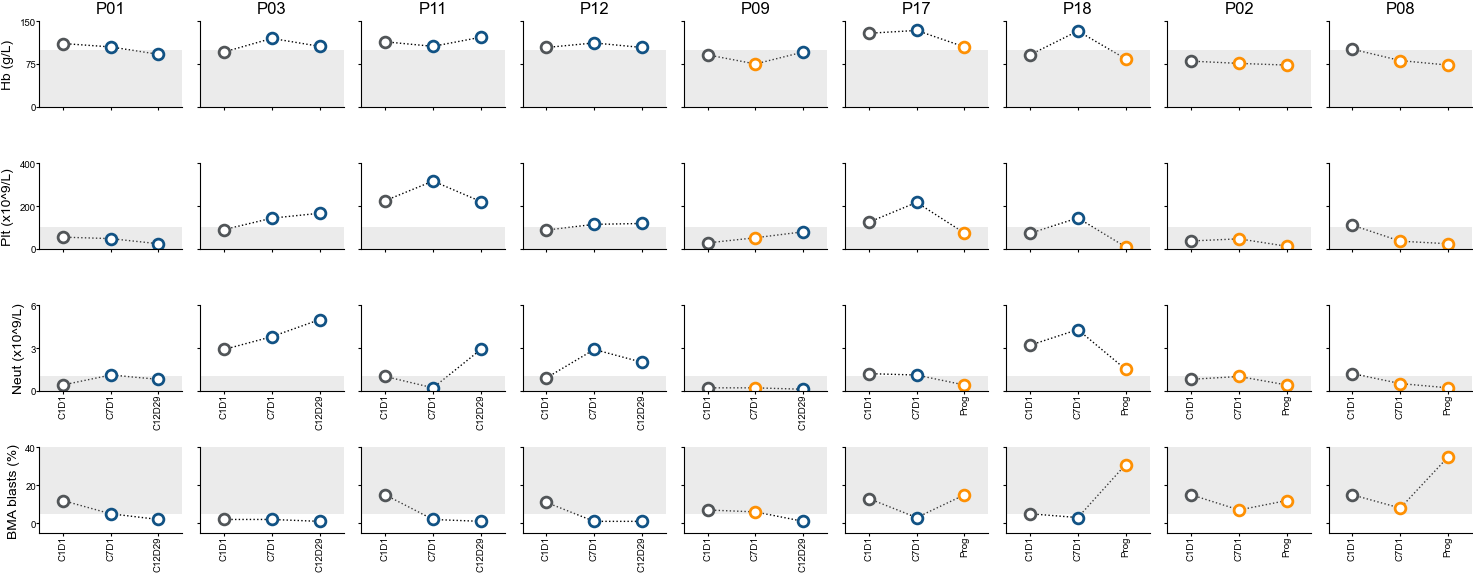

In [24]:
#Plotting the clinical data - healthy counts and blasts
fig, ax = plt.subplots(4,9, figsize = (15,6))
ax = ax.ravel()

for i, p in enumerate(patients):
    pr = pt_res[p]
    r1 = colors_dict[pr[1]] #C7 response for this patient
    r2 = colors_dict[pr[2]] #End response for this patient
    fcolor = 'silver'
    #for j, measure in enumerate(cdata['Analyte'].drop_duplicates().to_list()):
    for j, measure in enumerate(['Hb', 'Plt', 'Neut', 'blast']): #force the graph order
        z = i + (j*9)
        pdata = cdata.loc[(cdata['Patient']==p) & (cdata['Analyte']==measure)]
        x = [0,1,2]
        y = [pdata.Screen.values[0], pdata.C7D1.values[0], pdata.End.values[0]]
        ax[z].plot(x,y, color='k',linewidth=1, zorder = 1, linestyle = 'dotted')
        for d in range(3):
            ax[z].scatter(x[d],y[d], marker = 'o', color = 'white', edgecolor=colors_dict[pr[d]], linewidth=2, zorder = 2, s = 60)#can colour dots by response
        ax[z].set_xticks([0,1,2])
        ax[z].set_xticklabels([])
        ax[z].spines['top'].set_visible(False) 
        ax[z].spines['right'].set_visible(False) 
        ax[z].set_xlim(-0.5, 2.5)
        ax[z].tick_params(labelsize=7, length=2, pad=0)
        
        if z < 9:
            ax[z].set_title(f'{p}', y = 1.0, loc = 'center')  

        
        if z > 17:
            if p in ppats:
                ax[z].set_xticklabels(['C1D1', 'C7D1', 'Prog'], rotation=90)
            else:
                ax[z].set_xticklabels(['C1D1', 'C7D1', 'C12D29'], rotation=90)

        if measure == 'Hb':
            ax[z].set_ylim(0,150)
            ax[z].set_yticks([0,75,150])
            rect = mpatches.Rectangle(
                (-0.5,0),         # Bottom-left corner (x, y)
                3,  # Width
                Hb,                           # Height
                linewidth=0,
                edgecolor=None,
                facecolor=fcolor,
                alpha=0.3                      # Optional transparency
                )

            ax[z].add_patch(rect)

        
        elif measure == 'Plt':
            ax[z].set_ylim(0,400)
            ax[z].set_yticks([0,200,400])
            rect = mpatches.Rectangle(
                (-0.5,0),         # Bottom-left corner (x, y)
                3,  # Width
                Plt,                           # Height
                linewidth=0,
                edgecolor=None,
                facecolor= fcolor,
                alpha=0.3                      # Optional transparency
                )

            ax[z].add_patch(rect)

        
        elif measure == 'Neut':
            ax[z].set_ylim(0,6)
            ax[z].set_yticks([0,3,6])
            rect = mpatches.Rectangle(
                (-0.5,0),         # Bottom-left corner (x, y)
                3,  # Width
                Neut,                           # Height - add 1 here because of sub 0 offset (no longer used)
                linewidth=0,
                edgecolor=None,
                facecolor=fcolor,
                alpha=0.3                      # Optional transparency
                )

            ax[z].add_patch(rect)

        elif measure == 'blast':
            ax[z].set_ylim(-5,40)
            ax[z].set_yticks([0,20,40])
            rect = mpatches.Rectangle(
                (-0.5,5),         # Bottom-left corner (x, y)
                3,  # Width
                blast,                        
                linewidth=0,
                edgecolor=None,
                facecolor=fcolor,
                alpha=0.3                      # Optional transparency
                )
        
            ax[z].add_patch(rect)

        

        if p != 'P01':
            ax[z].set_yticklabels('')

ax[0].set_ylabel('Hb (g/L)',  x = 1.0, loc = 'center')
ax[9].set_ylabel('Plt (x10^9/L)', x = 1.0, loc = 'center')
ax[18].set_ylabel('Neut (x10^9/L)', x = 1.0, loc = 'center')
ax[27].set_ylabel('BMA blasts (%)', x = 1.0, loc = 'center')

fig.tight_layout()
            
#fig.savefig('../Figures/2_Clinical_counts_v1_GEO.pdf',bbox_inches='tight',format='pdf', dpi = 600)

In [25]:
#Calculating diversity in the healthy clusters

In [26]:
def compute_diversity_3(df, healthy_clusters, disease_clusters,
                      value_col="cell_number", mode="healthy_only"):
    """
    Compute Shannon diversity index for scRNAseq clusters.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['leiden', value_col, 'patient_alias', 'timepoint'].
    healthy_clusters : list
        List of leiden cluster IDs considered "healthy".
    disease_clusters : list
        List of leiden cluster IDs considered "disease".
    value_col : str
        Column in df with numeric values to use ("cell_number" or proportion).
    mode : str
        - "healthy_only" : diversity among healthy clusters only
        - "all_clusters" : diversity among all clusters (healthy + disease)
        - "collapse_disease" : healthy clusters + one "Disease" super-cluster

    Returns
    -------
    pd.DataFrame with Shannon diversity values per (patient_alias, timepoint).
    """

    df = df.copy()

    # Optionally collapse disease into one class
    if mode == "collapse_disease":
        df["cluster_group"] = df["leiden"].where(df["leiden"].isin(healthy_clusters), "Disease")
    elif mode == "healthy_only":
        df = df[df["leiden"].isin(healthy_clusters)].copy()
        df["cluster_group"] = df["leiden"]
    elif mode == "all_clusters":
        df["cluster_group"] = df["leiden"]
    else:
        raise ValueError("mode must be 'healthy_only', 'all_clusters', or 'collapse_disease'")

    # Group by patient, timepoint, and cluster_group
    grouped = (
        df.groupby(["patient_alias", "timepoint", "cluster_group"], observed=True)[value_col]
        .sum()
        .reset_index()
    )

    # Normalize within each (patient, timepoint) to get proportions
    grouped["proportion"] = grouped.groupby(["patient_alias", "timepoint"])[value_col] \
                                   .transform(lambda x: x / x.sum())

    # Shannon entropy per (patient, timepoint)
    div = grouped.groupby(["patient_alias", "timepoint"])["proportion"] \
                 .apply(lambda p: entropy(p, base=np.e)) \
                 .reset_index(name="shannon_diversity")

    div["mode"] = mode
    return div

In [30]:
#Data for diversity calculations
adata6 = adata.obs.copy()
#adata6['time'] = adata6['timepoint'].replace(time_dict)


df_numbs_all = None

for i, p in enumerate(patients):
    for t in ['C1', 'C7', 'End']: 

        adata1 = adata6.loc[(adata6['time'] == t) & (adata6['patient_alias']==p)]
        #print(adata1['leiden'].value_counts())

        # Calculate proportions of each cell type
        df = pd.DataFrame(adata1['leiden'].value_counts()).reset_index()
        df.columns = ['leiden', 'cell_number']

        #Get the total number of atypical cells and add in to dataframe
        atyp = df.loc[df['leiden'].isin(a_leiden_str)]['cell_number'].sum()
        heal = df.loc[df['leiden'].isin(h_leiden_str)]['cell_number'].sum()
        #print(atyp, heal)

        df.loc[len(df)] = ['Atyp', atyp] 
        df.loc[len(df)] = ['HSPC-L', heal] 

        #Add extra annotation columns
        df['patient_alias'] = p
        df['timepoint'] = t       

        if df_numbs_all is None:
            df_numbs_all = df.copy()
        else:
            df_numbs_all = pd.concat([df_numbs_all, df],ignore_index = True)

for i, p in enumerate(controls):
    for t in ['Healthy']: 

        adata1 = adata6.loc[(adata6['time'] == t) & (adata6['patient_alias']==p)]
        #print(adata1['leiden'].value_counts())

        # Calculate proportions of each cell type
        df = pd.DataFrame(adata1['leiden'].value_counts()).reset_index()
        df.columns = ['leiden', 'cell_number']

        #Get the total number of atypical cells and add in to dataframe
        atyp = df.loc[df['leiden'].isin(a_leiden_str)]['cell_number'].sum()
        heal = df.loc[df['leiden'].isin(h_leiden_str)]['cell_number'].sum()
        #print(atyp, heal)

        df.loc[len(df)] = ['Atyp', atyp] 
        df.loc[len(df)] = ['HSPC-L', heal] 

        #Add extra annotation columns
        df['patient_alias'] = p
        df['timepoint'] = t       

        if df_numbs_all is None:
            df_numbs_all = df.copy()
        else:
            df_numbs_all = pd.concat([df_numbs_all, df],ignore_index = True)
            
df_numbs_all2 = df_numbs_all.loc[~df_numbs_all['leiden'].isin(['Atyp', 'HSPC-L'])]
df_numbs_all2

,leiden,cell_number,patient_alias,timepoint
0,3,1279,P01,C1
1,14,271,P01,C1
2,1,70,P01,C1
3,17,64,P01,C1
4,23,31,P01,C1
...,...,...,...,...
889,8,0,C5,Healthy
890,7,0,C5,Healthy
891,4,0,C5,Healthy
892,3,0,C5,Healthy


In [32]:
div_collapse = compute_diversity_3(df_numbs_all2, h_leiden_str, a_leiden_str, mode="collapse_disease")
#div_collapse

C:\Users\z3283497\AppData\Local\Temp\ipykernel_56060\2447091477.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = [row[1], row[2], row[3]]
C:\Users\z3283497\AppData\Local\Temp\ipykernel_56060\2447091477.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = [row[1], row[2], row[3]]
C:\Users\z3283497\AppData\Local\Temp\ipykernel_56060\2447091477.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = [row[1], row[2]]
C:\Use

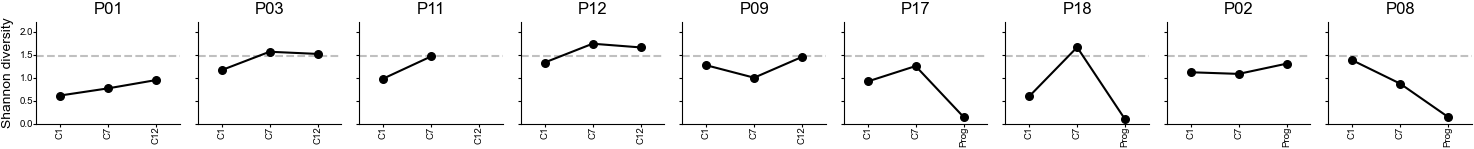

In [34]:
#Line plots of diversity dynamics
fig, ax = plt.subplots(1,9, figsize = (15, 1.75))

mhd = div_collapse.loc[div_collapse['patient_alias'].isin(controls)]['shannon_diversity'].mean()

for i, p in enumerate(patients):

    df = div_collapse.loc[div_collapse['patient_alias']==p]
    reshaped = df.pivot(index = 'patient_alias', columns = 'timepoint', values = 'shannon_diversity').reset_index()
    
    for j, row in reshaped.iterrows():
        if p == 'P11':
            y = [row[1], row[2]]
            x = [0,1]
            #print(p, x, y, color)
            ax[i].plot(x,y,color = 'k') 
            ax[i].scatter(x,y,marker = 'o', color = 'k', linewidth=1, zorder = 2, s = 30)
        else:
            y = [row[1], row[2], row[3]]
            x = [0,1,2]
            #print(p, x, y, color)
            ax[i].plot(x,y, color = 'k') 
            ax[i].scatter(x,y,marker = 'o', color = 'k', linewidth=1, zorder = 2, s = 30)

    ax[i].set_ylim(0,2.2)
    ax[i].set_title(f'{p}',y = 1.0)
    ax[i].set_xticks([0,1,2])
    ax[i].axhline(y=mhd, color='silver', linestyle='--', zorder=0)  #dotted line at average diversity in healthy patients
    if p in ppats:
        ax[i].set_xticklabels(['C1', 'C7', 'Prog'], rotation=90)
    else:
        ax[i].set_xticklabels(['C1', 'C7', 'C12'], rotation=90)
    ax[i].tick_params(length=2, pad=0)
    ax[i].spines['top'].set_visible(False) 
    ax[i].spines['right'].set_visible(False) 
    ax[i].set_xlim(-0.5, 2.5)
    ax[i].tick_params(labelsize=7, length=2, pad=0)

for g in range(8):
    ax[g+1].set_yticklabels('')
ax[0].set_ylabel('Shannon diversity')            

fig.tight_layout()

#fig.savefig('../Figures/2_Shannon_diversity_healthy_leiden_v1_GEO.pdf',bbox_inches='tight',format='pdf', dpi = 600)

In [35]:
diversity = div_collapse.loc[div_collapse['patient_alias'].isin(patients)]
#diversity

In [38]:
#Grab and reshape the patient data
clin_data = cdata.loc[cdata['Patient'].isin(patients)]
clin_data.columns = ['patient_alias', 'analyte', 'C1', 'C7', 'End']
#clin_data

df_long = clin_data.melt(
    id_vars=['patient_alias', 'analyte'],
    value_vars=['C1', 'C7', 'End'],
    var_name='timepoint',
    value_name='value'
)
#df_long

df_wide = df_long.pivot_table(
    index=['patient_alias', 'timepoint'],
    columns='analyte',
    values='value'
).reset_index()
#df_wide

correlation = diversity.merge(df_wide, on = ['patient_alias', 'timepoint'])
#correlation

In [40]:
#Add in response at each time
#Response df
rdf = pd.DataFrame.from_dict(pt_res).T.reset_index()
rdf.columns = ['patient_alias', 'C1', 'C7', 'End']
rdf2 = rdf.melt(id_vars = 'patient_alias', value_vars = ['C1', 'C7', 'End'])
rdf2.columns = ['patient_alias', 'timepoint', 'response']
#rdf2

correlation2 = correlation.merge(rdf2, on = ['patient_alias', 'timepoint'])
#correlation2

In [42]:
#Fabio suggested also plotting just %atypical vs % BM blasts as an entry point to the comparisons - need to build df to plot these
atyp_props_clin = df_props.loc[df_props['leiden']=='Atyp'].merge(df_wide, on = ['patient_alias', 'timepoint']).merge(rdf2, on = ['patient_alias', 'timepoint'])
atyp_props_clin = atyp_props_clin.loc[~((atyp_props_clin['patient_alias'] == 'P11') & (atyp_props_clin['timepoint'] == 'End'))] #need to exclude timepoint where there's no P11 citeseq data 
#atyp_props_clin

Regression line correlation for shannon diversity and Hb has r-value 0.36108360241025517 and p-value 0.06993621926575498
   
Regression line correlation for shannon diversity and Plt has r-value 0.46215172353718564 and p-value 0.017455231193577257
   
Regression line correlation for shannon diversity and Neut has r-value 0.38946197004900845 and p-value 0.04922378105954659
   
Regression line correlation for shannon diversity and blast has r-value -0.7269855877999802 and p-value 2.591807643431768e-05
   
Pearson correlation between shannon diversity and blast =  -0.7269855877999801  with p-value =  2.5918076434317675e-05
   
Pearson correlation between shannon diversity and Hb =  0.3610836024102552  with p-value =  0.06993621926575488
   
Pearson correlation between shannon diversity and Plt =  0.4621517235371857  with p-value =  0.017455231193577246
   
Pearson correlation between shannon diversity and Neut =  0.38946197004900845  with p-value =  0.049223781059546536
   


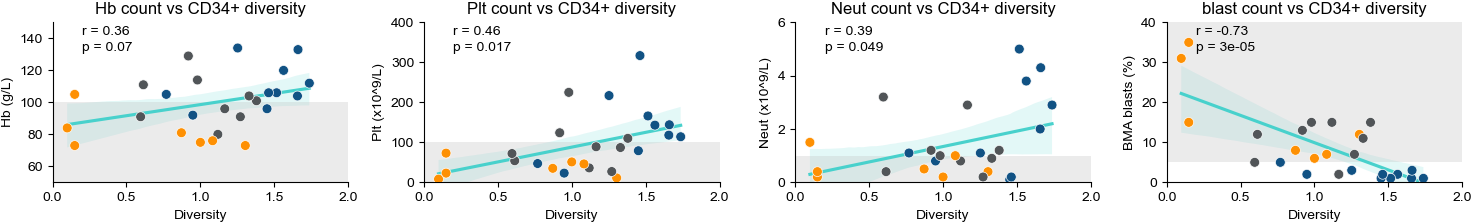

In [44]:
#Plot the correlations for Hb, Plt, Neut, blast
#Older workup code also include atypical cf blasts (theoretically the same thing)
fig, ax = plt.subplots(1, 4, figsize = (15, 2.5))

df = correlation2.loc[~correlation2['shannon_diversity'].isna()] #Need to exclude P11 with no diversity data at End

for i, g in enumerate(['Hb', 'Plt', 'Neut', 'blast']):
    #Plot the data
    if g in ['blast', 'Hb', 'Plt', 'Neut']:

        slope, intercept, r_value, pv, se = st.linregress(df['shannon_diversity'], df[g])
        print(f'Regression line correlation for shannon diversity and {g} has r-value {r_value} and p-value {pv}')
        print('   ')
        sns.scatterplot(x = 'shannon_diversity', y = g, data = df, hue = 'response', palette = colors_dict, ax = ax[i], zorder = 10)
        ax[i].collections[0].set_sizes([50])   #set the scatterplot marker size
        sns.regplot(x = 'shannon_diversity', y = g, data = df, ax = ax[i], line_kws={'label':'$y=%3.7s*x+%3.7s$'%(slope, intercept)}, scatter_kws={'s':1}, color = 'mediumturquoise')  
        #ax[i].axvline(x=mhd, color='silver', linestyle='--', zorder=0) #Healthy average - optionally turn on
        ax[i].set_xlim(0,2)
        #ax[i].legend(loc = 'upper center',bbox_to_anchor = [0.5,-0.3], ncols = 1) #Optionl turn on for legend (and hash out next line)
        ax[i].get_legend().remove()
        ax[i].set_title(f'{g} count vs CD34+ diversity')
        ax[i].spines['top'].set_visible(False) 
        ax[i].spines['right'].set_visible(False) 
        

    #Axes specfications

    if g == 'Hb':
            ax[i].set_ylim(50,150)
            ax[i].text(0.2,(50+92),f'r = {round(r_value, 2)}')
            ax[i].text(0.2,(50+82),f'p = {round(pv, 3)}')
            rect = mpatches.Rectangle(
                (-0.5,0),         # Bottom-left corner (x, y)
                3,  # Width
                Hb,                           # Height
                linewidth=0,
                edgecolor=None,
                facecolor=fcolor,
                alpha=0.3                      # Optional transparency
                )
    
            ax[i].add_patch(rect)
            ax[i].set_ylabel('Hb (g/L)', x = 1.0, loc = 'center')
            ax[i].set_xlabel('Diversity')
    
        
    elif g == 'Plt':
        ax[i].set_ylim(0,400)
        ax[i].text(0.2,(0.92*400),f'r = {round(r_value, 2)}')
        ax[i].text(0.2,(0.82*400),f'p = {round(pv, 3)}')
        rect = mpatches.Rectangle(
            (-0.5,0),         # Bottom-left corner (x, y)
            3,  # Width
            Plt,                           # Height
            linewidth=0,
            edgecolor=None,
            facecolor= fcolor,
            alpha=0.3                      # Optional transparency
            )
    
        ax[i].add_patch(rect)
        ax[i].set_ylabel('Plt (x10^9/L)', x = 1.0, loc = 'center') 
        ax[i].set_xlabel('Diversity')
    
    
    elif g == 'Neut':
        ax[i].set_ylim(0,6)
        ax[i].text(0.2,(0.92*6),f'r = {round(r_value, 2)}')
        ax[i].text(0.2,(0.82*6),f'p = {round(pv, 3)}')
        rect = mpatches.Rectangle(
            (-0.5,0),         # Bottom-left corner (x, y)
            3,  # Width
            Neut,                           # Height - add 1 here because of sub 0 offset (no longer used)
            linewidth=0,
            edgecolor=None,
            facecolor=fcolor,
            alpha=0.3                      # Optional transparency
            )
    
        ax[i].add_patch(rect)
        ax[i].set_ylabel('Neut (x10^9/L)', x = 1.0, loc = 'center')
        ax[i].set_xlabel('Diversity')
    
    elif g == 'blast':
        ax[i].set_ylim(0,40)
        ax[i].text(0.2,(0.92*40),f'r = {round(r_value, 2)}')
        ax[i].text(0.2,(0.82*40),f'p = {round(pv, 5)}')
        rect = mpatches.Rectangle(
            (-0.5,5),         # Bottom-left corner (x, y)
            3,  # Width
            blast,                        
            linewidth=0,
            edgecolor=None,
            facecolor=fcolor,
            alpha=0.3                      # Optional transparency
            )
    
        ax[i].add_patch(rect)
        ax[i].set_ylabel('BMA blasts (%)', x = 1.0, loc = 'center')
        ax[i].set_xlabel('Diversity')
      


fig.tight_layout()

#Add in some stats
for k in ['blast', 'Hb', 'Plt', 'Neut']:
    print(f'Pearson correlation between shannon diversity and {k} = ', st.pearsonr(df['shannon_diversity'], df[k])[0], ' with p-value = ', st.pearsonr(df['shannon_diversity'], df[k])[1])
    print('   ')


#fig.savefig('../Figures/2_Shannon_diversity_leiden_healthy_correlation_cell_counts_v1_GEO.pdf',bbox_inches='tight',format='pdf', dpi = 600)